# Lab session 3: Federated Learning

**What is federated learning?**
Federated Learning (FL) is a way to train ML models without moving (potentially sensitive) data from one server (e.g. hospital) to another.

<br>Instead of sending all data to one central place, each site (or client):

1. Receives a copy of a global model

2. Trains it locally on its own data

3. Sends **only the updated weights** back

4. A central server averages these updates 

5. The averaged global model is redistributed 

<br>By doing this:
- No raw data is ever shared, each site can keep its own dataset private (this is important in a healthcare setting)
- All sites still benefit from each other’s data and overall model performance can improve

<p align="center">
  <img src="https://blog.ml.cmu.edu/wp-content/uploads/2019/11/Screen-Shot-2019-11-12-at-10.42.34-AM-1024x506.png"
       width="600">
</p>


## 0. Import and dataset

In [ ]:
!pip install tensorflow

In [1]:
import os, zipfile, glob
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings("ignore")

# ensure reproducibility 
SEED=42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

Get the dataset (**modify this according to your setup**)

In [2]:
# zip_path = "wbc_cr_healthy_medium.zip"
# extract_dir = "data/"

# # create folder for data dir
# os.makedirs(extract_dir, exist_ok=True)

# # unzip
# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_dir)

# #data_dir = "/content/data/wbc_cr_healthy_medium/"
data_dir = "wbc_cr_healthy_medium/wbc_cr_healthy_medium"

What classes are there? 
<br>**Hint:** loop through the folders in the dataset

In [ ]:
# Iterate over files in directory
classes = []
for root, dirs, files in os.walk(data_dir, topdown=True):
    for dir in dirs:
        print(dir)
        classes.append(dir)

Basophile
Eosinophile
Lymphocyte
Monocyte
Neutrophile Segment


In [4]:
for c in classes:
    print(c)

Basophile
Eosinophile
Lymphocyte
Monocyte
Neutrophile Segment


Organise dataset as a dataframe (nothing to do here)

In [5]:
image_paths = []
labels = []
for cls in classes:
    for f in glob.glob(os.path.join(data_dir, cls, '*.png')):
        image_paths.append(f)
        labels.append(cls)
df = pd.DataFrame({'filename': image_paths, 'label': labels})
df.head()

,filename,label
0,wbc_cr_healthy_medium/wbc_cr_healthy_medium\Ba...,Basophile
1,wbc_cr_healthy_medium/wbc_cr_healthy_medium\Ba...,Basophile
2,wbc_cr_healthy_medium/wbc_cr_healthy_medium\Ba...,Basophile
3,wbc_cr_healthy_medium/wbc_cr_healthy_medium\Ba...,Basophile
4,wbc_cr_healthy_medium/wbc_cr_healthy_medium\Ba...,Basophile


## 1. Expolatory data analysis
- What does the data look like?
- How many classes are there? How many samples per class?
- Are there any data imabalances?

In [ ]:
# how many classes are there
print("Number of classes:", len(classes))

# how many samples per class
print("\nSamples (images) per class:")
for cls in classes:
    count = df['label'].value_counts()[cls]
    print(f"{cls}: {count} samples")


Number of classes: 5

Samples (images) per class:
Basophile: 409 samples
Eosinophile: 406 samples
Lymphocyte: 401 samples
Monocyte: 389 samples
Neutrophile Segment: 456 samples


Plot some datapoints

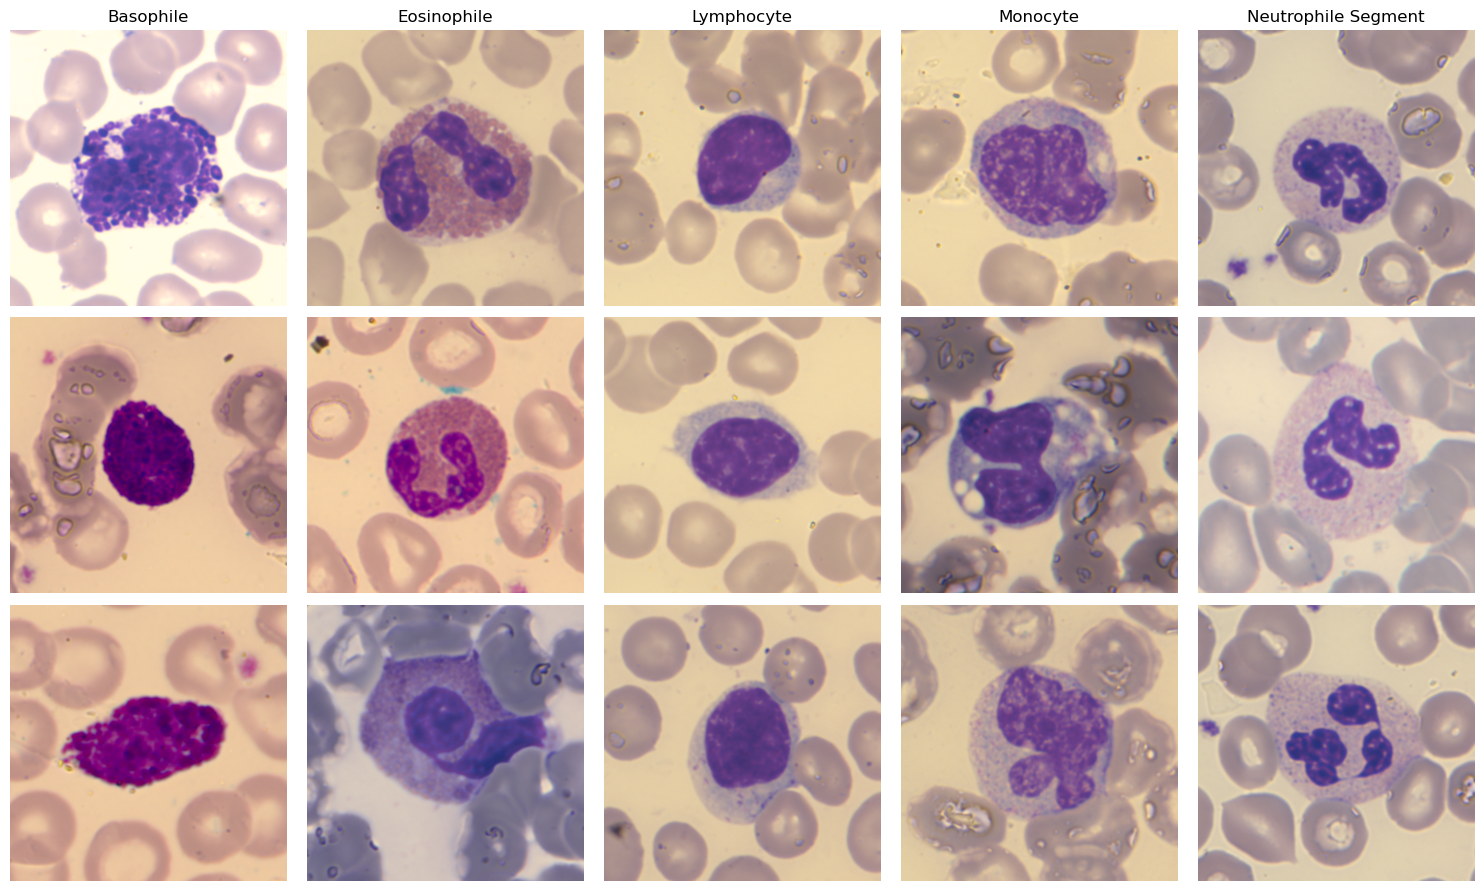

In [ ]:
plt.figure(figsize=(15, 9))

samples_per_class = 3

for i, c in enumerate(classes):
    class_path = os.path.join(data_dir, c)
    sample_images = random.sample(os.listdir(class_path), k=samples_per_class)  # 3 random images per class

    for j, img_name in enumerate(sample_images):
        img_path = os.path.join(class_path, img_name)
        img = mpimg.imread(img_path)

        plt.subplot(samples_per_class, len(classes), j*len(classes) + i + 1)
        plt.imshow(img)
        if j == 0:
            plt.title(c, fontsize=12)
        plt.axis('off')

plt.tight_layout()
plt.show()

## 2. Prepare the dataset

To simulate a federated learning scenario, we will create two training centres that have different distributions of the data: 


**Centre 1**

- All classes except Monocyte
(or very few Monocyte samples)

**Centre 2**

- All classes except Neutrophile Segment
(or very few Neutrophile Segment samples)

<br>**We therefore split the entire dataset into:**

1. Training set 

- This includes the images that each centre will use to train its local model.
- Includes a validation set (not test).

2. Test set (held out until the very end)

- This is a **completely separate** dataset.
- You should not look at it or use it during training.
- Only used once, at the end, to evaluate how well each model generalises.



Create a general train ant test split

In [8]:
df_train, df_test = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=SEED)
len(df_train), len(df_test)

(1648, 413)

Allocate data to Centre 1 and Centre 2

<br>**Note:** Even though each centre is supposed to “miss” one class, we still include a very small number of samples from that class. This keeps the setup stable for this illustrative federated learning scenario.
<br>**Hint:** See how changing the number of samples (e.g., 0 samples) affects FL later on. 

In [9]:
print("\nCentre 1")
# Centre 1 lacks Monocyte
df_other_c1 = df_train[df_train.label != "Monocyte"]
# add very few monocytes
df_mono_few = df_train[df_train.label == "Monocyte"].sample(10, random_state=SEED)
df_c1 = pd.concat([df_other_c1, df_mono_few])

print(df_c1.label.value_counts())

print("\nCentre 2")
# Centre 2 lacks NS
df_other_c2 = df_train[df_train.label != "Neutrophile Segment"]
# add very few NS
df_neutro_few = df_train[df_train.label == "Neutrophile Segment"].sample(10, random_state=SEED)
df_c2 = pd.concat([df_other_c2, df_neutro_few])

print(df_c2.label.value_counts())


Centre 1
label
Neutrophile Segment    364
Basophile              327
Eosinophile            325
Lymphocyte             321
Monocyte                10
Name: count, dtype: int64

Centre 2
label
Basophile              327
Eosinophile            325
Lymphocyte             321
Monocyte               311
Neutrophile Segment     10
Name: count, dtype: int64


Split Centre data into training and validation

In [10]:
df_c1_train, df_c1_val = train_test_split(
    df_c1, test_size=0.1, stratify=df_c1["label"], random_state=SEED)

df_c2_train, df_c2_val = train_test_split(
    df_c2, test_size=0.1, stratify=df_c2["label"], random_state=SEED)

Prepare image generators for CNN classifier
- Centre 1: training and validation 
- Centre 2: training and validation 
- Global test set

In [11]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
datagen = ImageDataGenerator(rescale=1./255)


CLASSES = sorted(os.listdir(data_dir))

print("Centre 1")
train_c1 = datagen.flow_from_dataframe(
    df_c1_train,
    x_col="filename",
    y_col="label",
    classes=CLASSES,       # force full class list to have 5 outputs (important for later)
    target_size=IMG_SIZE,
    class_mode="categorical",
    batch_size=BATCH_SIZE, 
    seed=SEED
)
val_c1 = datagen.flow_from_dataframe(
    df_c1_val,
    x_col="filename",
    y_col="label",
    classes=CLASSES,
    target_size=IMG_SIZE,
    class_mode="categorical",
    batch_size=BATCH_SIZE, 
    seed=SEED
)

print("\nCentre 2")
train_c2 = datagen.flow_from_dataframe(
    df_c2_train,
    x_col="filename",
    y_col="label",
    classes=CLASSES,
    target_size=IMG_SIZE,
    class_mode="categorical",
    batch_size=BATCH_SIZE, 
    seed=SEED
)
val_c2 = datagen.flow_from_dataframe(
    df_c2_val,
    x_col="filename",
    y_col="label",
    classes=CLASSES,
    target_size=IMG_SIZE,
    class_mode="categorical",
    batch_size=BATCH_SIZE, 
    seed=SEED
)

print("\nGobal test set")
test_gen = datagen.flow_from_dataframe(
    df_test,
    x_col="filename",
    y_col="label",
    classes=CLASSES,
    target_size=IMG_SIZE,
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False, 
    seed=SEED
)


Centre 1
Found 1212 validated image filenames belonging to 5 classes.
Found 135 validated image filenames belonging to 5 classes.

Centre 2
Found 1164 validated image filenames belonging to 5 classes.
Found 130 validated image filenames belonging to 5 classes.

Gobal test set
Found 413 validated image filenames belonging to 5 classes.


## 3. Train a CNN classifier independently for each model

Build a simple CNN classifier architecture to be used for all models (Centre 1, Centre 2 and FL model).

<br> **Hint:** Be mindful of the number of parameters so that training time remains reasonable for the lab - you will train quite a few models!

In [12]:
def build_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, 3, activation='relu', input_shape=(128, 128, 3)),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(128, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(len(CLASSES), activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

**Train Centre 1 model**

In [16]:
model_c1 = build_model()
history_c1 = model_c1.fit(train_c1, epochs=8, validation_data=val_c1) # YOUR CODE HERE... don't forget the validation split!

Epoch 1/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 27s 636ms/step - accuracy: 0.3243 - loss: 1.4274 - val_accuracy: 0.5185 - val_loss: 1.1118
Epoch 2/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 222ms/step - accuracy: 0.6394 - loss: 0.9325 - val_accuracy: 0.7704 - val_loss: 0.6762
Epoch 3/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 212ms/step - accuracy: 0.8003 - loss: 0.6057 - val_accuracy: 0.9037 - val_loss: 0.3490
Epoch 4/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 233ms/step - accuracy: 0.8762 - loss: 0.4100 - val_accuracy: 0.9037 - val_loss: 0.3303
Epoch 5/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 206ms/step - accuracy: 0.8903 - loss: 0.3182 - val_accuracy: 0.8963 - val_loss: 0.3284
Epoch 6/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 211ms/step - accuracy: 0.8663 - loss: 0.3578 - val_accuracy: 0.9111 - val_loss: 0.4142
Epoch 7/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 212ms/step - accuracy: 0.9208 - loss: 0.2195 - val_accuracy: 0.9037 - val_loss: 0.3425
Epoch 8/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 214ms/step - accuracy: 0.9274 - loss: 0.2003 - val_accuracy: 0.8444 - 

**Train Centre 2 model**

In [ ]:
model_c2 = build_model()
history_c2 = model_c2.fit(train_c2, epochs=8, validation_data=val_c2) # YOUR CODE HERE... don't forget the validation split!

Epoch 1/8
37/37 ━━━━━━━━━━━━━━━━━━━━ 14s 336ms/step - accuracy: 0.4192 - loss: 1.2658 - val_accuracy: 0.6462 - val_loss: 0.8677
Epoch 2/8
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 223ms/step - accuracy: 0.7010 - loss: 0.7522 - val_accuracy: 0.7846 - val_loss: 0.5722
Epoch 3/8
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 225ms/step - accuracy: 0.7629 - loss: 0.5510 - val_accuracy: 0.7385 - val_loss: 0.5667
Epoch 4/8
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 222ms/step - accuracy: 0.8230 - loss: 0.4274 - val_accuracy: 0.8077 - val_loss: 0.5363
Epoch 5/8
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 220ms/step - accuracy: 0.8471 - loss: 0.3824 - val_accuracy: 0.7846 - val_loss: 0.5096
Epoch 6/8
37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 229ms/step - accuracy: 0.8875 - loss: 0.2730 - val_accuracy: 0.8615 - val_loss: 0.5067
Epoch 7/8
37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 242ms/step - accuracy: 0.8840 - loss: 0.2854 - val_accuracy: 0.8231 - val_loss: 0.4541
Epoch 8/8
37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 238ms/step - accuracy: 0.8643 - loss: 0.3467 - val_accuracy: 0.8923 - 

**Evaluate** on the whole, **unseen** test set (with all classes)
- Compute accuracy both on *all* classes and on the "seen": classes only.
- Each centre is "missing" one class in its training data, so excluding that class gives a fair measure of how well the model performs on the classes it *actually* saw during training, compared to its overall (global) performance. 

In [27]:
def evaluate(model, generator, class_names, seen_classes, center_name="Model"):

    y_true = np.array(generator.classes).reshape(-1)

    # predict probas
    y_prob = model.predict(generator, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    # results dict
    results = {}

    # global accuracy
    global_acc = accuracy_score(y_true, y_pred)
    results["global_accuracy"] = global_acc

    # per-class accuracy
    class_acc = {}
    for i, cls in enumerate(class_names):
        idx = np.where(y_true == i)[0]
        if len(idx) > 0:
            class_acc[cls] = accuracy_score(y_true[idx], y_pred[idx])
        else:
            class_acc[cls] = None
    results["class_accuracy"] = class_acc

    # accuracy on seen classes
    seen_idx = [class_names.index(k) for k in seen_classes]
    mask = np.isin(y_true, seen_idx)

    if np.sum(mask) > 0:
        seen_acc = accuracy_score(y_true[mask], y_pred[mask])
    else:
        seen_acc = None
    results["seen_class_accuracy"] = seen_acc

    print(f"{center_name}")
    print(f"Global accuracy: {global_acc*100:.2f}%")
    print(f"Seen-classes accuracy: {seen_acc*100:.2f}%")

    print("\nClass-wise Accuracy:")
    for cls, acc in class_acc.items():
        print(f"{cls:<25} :  {acc*100:6.2f}%")

    print("\n")

    # plot a confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=class_names)

    plt.figure(figsize=(6, 5))
    disp.plot(cmap="Blues", values_format="d", colorbar=False)
    plt.title(f"{center_name} confusion matrix")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

    return results

Separate out "missing" class to have stratified evaluation. 

In [28]:
ALL_CLASSES = CLASSES 

seen_classes_c1 = [c for c in ALL_CLASSES if c != "Monocyte"]
seen_classes_c2 = [c for c in ALL_CLASSES if c != "Neutrophile Segment"]

How does Centre 1 perform?

Model
Global accuracy: 68.77%
Seen-classes accuracy: 84.78%

Class-wise Accuracy:
Basophile                 :   95.12%
Eosinophile               :   88.89%
Lymphocyte                :   80.00%
Monocyte                  :    0.00%
Neutrophile Segment       :   76.09%




<Figure size 600x500 with 0 Axes>

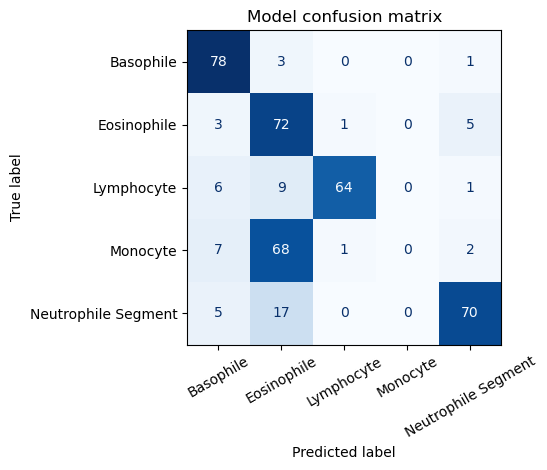

In [29]:
results_c1 = evaluate(model_c1, test_gen, class_names=ALL_CLASSES, seen_classes=seen_classes_c1) # YOUR CODE HERE... don't forget to evaluate on the correct test set!

How does Centre 2 perform?

Model
Global accuracy: 68.77%
Seen-classes accuracy: 85.67%

Class-wise Accuracy:
Basophile                 :   87.80%
Eosinophile               :   76.54%
Lymphocyte                :  100.00%
Monocyte                  :   78.21%
Neutrophile Segment       :    9.78%




<Figure size 600x500 with 0 Axes>

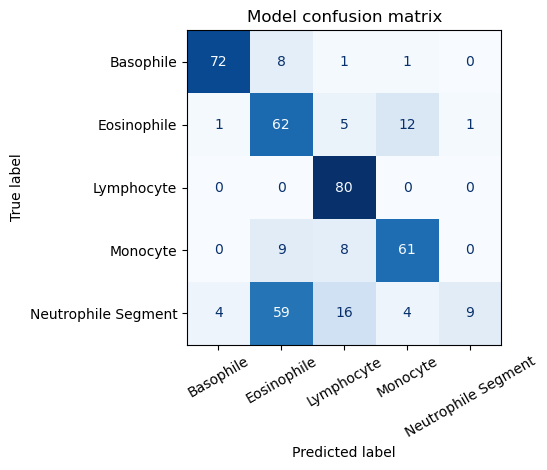

In [30]:
results_c2 = evaluate(model_c2, test_gen, ALL_CLASSES, seen_classes_c2) # YOUR CODE HERE... don't forget to evaluate on the correct test set!


## 4. Federated Learning 

For now, we have seen: 
- how each centre performs on its own
- how well or poorly each model performs on seen vs unseen classes 

In this part, we will implement a federated learning (FL) algorithm to mitigate performance drops on unseen classes:

- We start with a **global model**

- Send the model to each centre

- Each centre trains locally on **its own data** (for `n_epochs_per_round`)

- Centres send back their **updated weights**

- We **average** these updates 

- The improved global model is **redistributed** 

- Repeat for to `n_rounds`

Because the centres are missing different classes, sharing updates (weights) allows the global model to learn from both datasets.


<p align="center">
  <img src="https://miro.medium.com/v2/resize:fit:1400/format:webp/1*G7cu8M6UlMsssARt9Kp4iQ.jpeg"
       width="600">
</p>


Some helper functions to get and distribute weights: 

In [31]:
def get_weights(model):
    return model.get_weights()

def set_weights(model, weights):
    model.set_weights(weights)

Function to implement **federated averageing**
- Each centre’s weights are averaged and *weighted* by its number of training samples
=> Centres with more data have a proportionally *larger influence* on the global update

<br>**Hint:** Use formula above

In [32]:
# compute federated averaging (weighted by nb of samples)
def weighted_fedavg(weights_list, sizes):
    total = sum(sizes)
    new_weights = []
    for layer_weights in zip(*weights_list):
        new_layer = np.zeros_like(layer_weights[0])
        for w, n in zip(layer_weights, sizes):

            new_layer += w * (n / total)
            
        new_weights.append(new_layer)
    return new_weights

Initialise **global** model with pre-trained weights (faster convergence)

In [33]:
# get weights from previous models (trained on 5 epochs)
w1_base = get_weights(model_c1)
w2_base = get_weights(model_c2)

# size of centre 1 and centre 2 training sets
sizes = [train_c1.n, train_c2.n] # YOUR CODE HERE... [size_centre_1, size_centre_2]

# start with weighted average of existing models
global_weights = weighted_fedavg([w1_base, w2_base], sizes)

# instantiate global model 
global_model = build_model()

# set starting weights (averaged)
global_model.set_weights(global_weights)
print("Global model initialised with pre-trained client weights.")


Global model initialised with pre-trained client weights.


**Start FL loop**

<br>**Hint:** Follow the steps described earlier (send global model --> local training --> return updates --> average --> repeat).

**Hint:** change number of rounds and epochs depending on your compute power. Ideally, you want at least 2 epochs per round and 2/3 rounds. 

In [34]:
num_rounds = 5
epochs_per_round = 8

# client models
model_c1_fl = build_model()
model_c2_fl = build_model()

for rnd in range(num_rounds):

    print(f"\n Round {rnd+1}")

    ## Client 1
    # Step 1: assign weights
    model_c1_fl.set_weights(global_weights) # YOUR CODE HERE... which weights should you assign?
    # Step 2: train on updated weights (or initial weights if first loop)
    model_c1_fl.fit(train_c1, epochs=epochs_per_round, verbose=0) # YOUR CODE HERE...
    # Step 3: save the new weights
    w1 = model_c1_fl.get_weights() # YOUR CODE HERE... 

    ## Client 2
    # YOUR CODE HERE... same as Client 1
    model_c2_fl.set_weights(global_weights) # YOUR CODE HERE... which weights should you assign?
    # Step 2: train on updated weights (or initial weights if first loop)
    model_c2_fl.fit(train_c2, epochs=epochs_per_round, verbose=0) # YOUR CODE HERE...
    # Step 3: save the new weights
    w2 = model_c2_fl.get_weights() # YOUR CODE HERE... 

    ## Federated averaging
    # Step 1: compute new averaged weights
    global_weights = weighted_fedavg([w1, w2], sizes) # YOUR CODE HERE... hint: weighted_fedavg
    # Step 2: assign new weights to global model
    global_model.set_weights(global_weights) # YOUR CODE HERE... 

    # global testing (just for monitoring)
    _, acc = global_model.evaluate(test_gen, verbose=0)
    print(f"Global accuracy after round {rnd+1}: {acc*100:.2f}%")


 Round 1
Global accuracy after round 1: 63.92%

 Round 2
Global accuracy after round 2: 81.84%

 Round 3
Global accuracy after round 3: 79.18%

 Round 4
Global accuracy after round 4: 84.26%

 Round 5
Global accuracy after round 5: 84.99%


How does the Global model perform?
<br> How has class-wise performance changed?

Federated Model
Global accuracy: 84.99%
Seen-classes accuracy: 84.99%

Class-wise Accuracy:
Basophile                 :   93.90%
Eosinophile               :   83.95%
Lymphocyte                :   97.50%
Monocyte                  :   64.10%
Neutrophile Segment       :   84.78%




<Figure size 600x500 with 0 Axes>

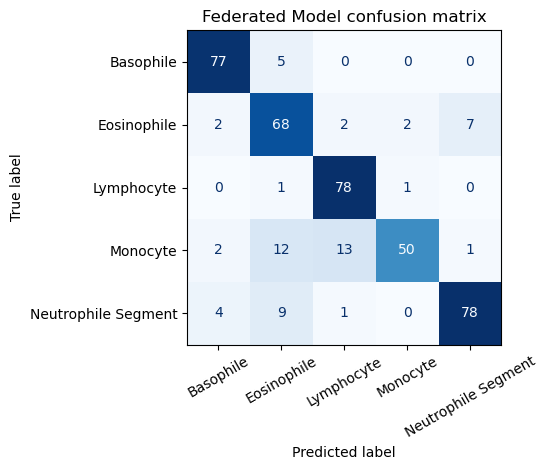

{'global_accuracy': 0.8498789346246973,
 'class_accuracy': {'Basophile': 0.9390243902439024,
  'Eosinophile': 0.8395061728395061,
  'Lymphocyte': 0.975,
  'Monocyte': 0.6410256410256411,
  'Neutrophile Segment': 0.8478260869565217},
 'seen_class_accuracy': 0.8498789346246973}

In [35]:
evaluate(
    global_model, 
    test_gen, 
    class_names=ALL_CLASSES, 
    seen_classes=ALL_CLASSES, 
    center_name="Federated Model"
) # YOUR CODE HERE... 

## 5. Federated learning with `flower`: you can also get familiar with an online package to run FL simulations

https://flower.ai/docs/framework/tutorial-quickstart-tensorflow.html

In [ ]:
!pip install -U "flwr[simulation]"
!pip install --upgrade pip setuptools wheel